# Student Performance Prediction — Model Training & Optimization

## Project Overview
This notebook documents the training, hyperparameter tuning, evaluation, and comparison of multiple machine learning models for the Student Dropout Risk Prediction project.

## Objective
- Train multiple machine learning models
- Perform hyperparameter tuning
- Evaluate models on a held-out test set
- Compare performance using standardized metrics
- Select the best-performing model for deployment

## Environment Setup

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from student_management.training import train_model
from student_management.evaluate import evaluate_model

## Model 1 — Logistic Regression (Hyperparameter Tuned)

Logistic Regression is used as a baseline linear classifier.

The model is trained with hyperparameter tuning to optimize regularization strength and class weighting. Performance is evaluated on a stratified test split.


In [3]:
train_model(
    data_path="../data/sample_students.csv",
    model_type="logistic",
    out_dir="../models/logistic_tuned",
    tune=True
)

Model saved to: ../models/logistic_tuned/model.joblib
Test data saved to: ../models/logistic_tuned/test_data.joblib


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Internet_Access',
                                                   'Study_Hours_per_Day',
                                                   'Attendance_Rate',
                                                   'Assignment_Delay_Days',
                                                   'Travel_Time_Minutes',
                                                   'Part_Time_Job',
                                                   'Scholarship',
                                                   'Stress_Index',
                                                   'Semester_GPA', 'CGPA',
                                                   'Income_Stress_Ratio',
                                                   'GPA_vs_CGPA', 'GPA_vs_SGPA',
                                                   'Job_Stress_Interaction',
                                                   'Student_Pressure_Index',
                                                   'Academic_Risk']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Parental_Education',
                                                   'Dept_Semester'])])),
                ('model', LogisticRegression(C=0.01, max_iter=2000))])

Evaluation on TEST set only
Accuracy: 0.814
Precision: 0.7988610644657248
Recall: 0.814
F1 Score: 0.794108746691391
ROC-AUC: 0.8212005959794988


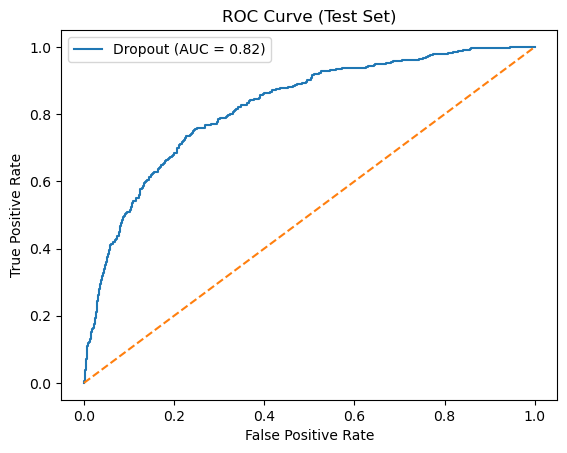

In [4]:
logistic_metrics = evaluate_model("../models/logistic_tuned")

## Model 2 — Random Forest (Hyperparameter Tuned)

Random Forest is an ensemble-based tree model that captures nonlinear feature interactions.

Hyperparameter tuning is applied to optimize tree depth, number of estimators, and split criteria. The model is evaluated using ROC-AUC and classification metrics.

In [5]:
train_model(
    data_path="../data/sample_students.csv",
    model_type="rf",
    out_dir="../models/rf_tuned",
    tune=True
)

Model saved to: ../models/rf_tuned/model.joblib
Test data saved to: ../models/rf_tuned/test_data.joblib


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Internet_Access',
                                                   'Study_Hours_per_Day',
                                                   'Attendance_Rate',
                                                   'Assignment_Delay_Days',
                                                   'Travel_Time_Minutes',
                                                   'Part_Time_Job',
                                                   'Scholarship',
                                                   'Stress_Index',
                                                   'Semester_GPA', 'CGPA',
                                                   'Income_St...
                                                   'Student_Pressure_Index',
                                                   'Academic_Risk']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Parental_Education',
                                                   'Dept_Semester'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=5, n_estimators=400,
                                        random_state=42))])

Evaluation on TEST set only
Accuracy: 0.7765
Precision: 0.8042642239364189
Recall: 0.7765
F1 Score: 0.7860380414901258
ROC-AUC: 0.8086061550296532


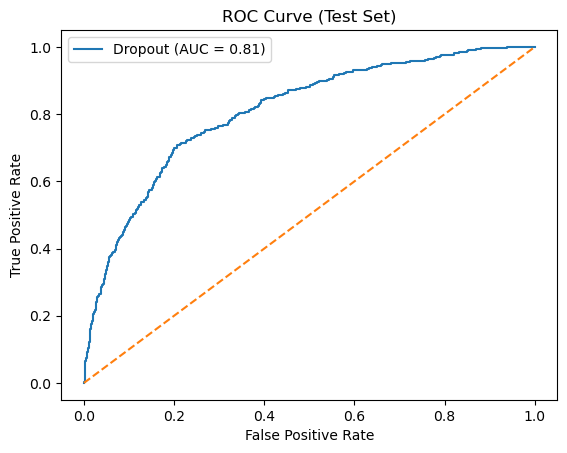

In [6]:
rf_metrics = evaluate_model("../models/rf_tuned")

## Model 3 — XGBoost (Hyperparameter Tuned)

XGBoost is a gradient boosting algorithm optimized for structured/tabular data.

Hyperparameter tuning is performed to optimize boosting depth, learning rate, and sampling ratios. The model is evaluated on the held-out test set for fair comparison.

In [7]:
train_model(
    data_path="../data/sample_students.csv",
    model_type="xgb",
    out_dir="../models/xgb_tuned",
    tune=True
)

Model saved to: ../models/xgb_tuned/model.joblib
Test data saved to: ../models/xgb_tuned/test_data.joblib


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Internet_Access',
                                                   'Study_Hours_per_Day',
                                                   'Attendance_Rate',
                                                   'Assignment_Delay_Days',
                                                   'Travel_Time_Minutes',
                                                   'Part_Time_Job',
                                                   'Scholarship',
                                                   'Stress_Index',
                                                   'Semester_GPA', 'CGPA',
                                                   'Income_St...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

Evaluation on TEST set only
Accuracy: 0.807
Precision: 0.7898774589535063
Recall: 0.807
F1 Score: 0.7887909204783433
ROC-AUC: 0.8061553073696225


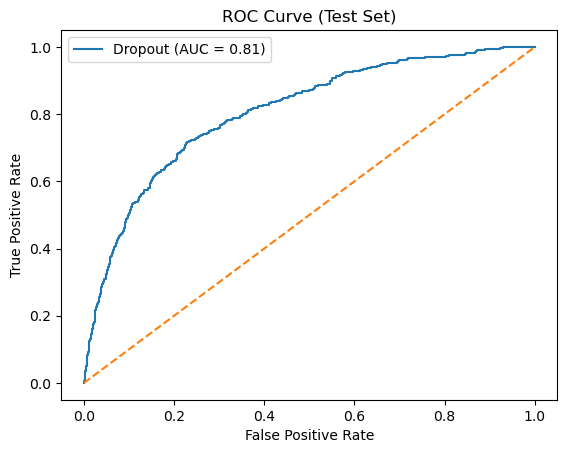

In [8]:
xgb_metrics = evaluate_model("../models/xgb_tuned")

## Model Comparison

The following table summarizes performance across all tuned models using standard classification metrics.


In [9]:
import pandas as pd

comparison_df = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    xgb_metrics
], index=["Logistic Regression", "Random Forest", "XGBoost"])

comparison_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8140,0.798861,0.8140,0.794109,0.821201
Random Forest,0.7765,0.804264,0.7765,0.786038,0.808606
XGBoost,0.8070,0.789877,0.8070,0.788791,0.806155


## Final Model Selection

The best model is selected based on the highest ROC-AUC score on the test set.

The selected model will be used for downstream deployment and inference.

In [10]:
best_model_name = comparison_df["roc_auc"].idxmax()
print("Best Model Based on ROC-AUC:", best_model_name)

Best Model Based on ROC-AUC: Logistic Regression
